<div align="center">
  <h1><b>Universidad Nacional Autónoma de México</b></h1>
  <h2><b>Facultad de Ciencias</b></h2>
  <br>
  <h3><b>Práctica de Análisis Numérico</b></h3>
  <h4>Semestre 2026-2</h4>
  <p>Dra. Úrsula Iturrarán Viveros</p>
  <p>Alumnos:
  
 Galán Resendiz Andres Roberto

 Valentino Hernández Gael Emiliano
</div>
<hr>

# Integración gaussiana

# **Ajuste por mínimos cuadrados lineales**

## Ejercicio 1

Supongamos una canica que se encuentra en caída libre vertical. Este movimiento se puede describir mediante el polinomio:

$$h(t) = a_0 + a_1t + a_2t^2$$

donde $h(t)$ es la altura que alcanza la canica como función del tiempo $t$.

Escribe un programa que, mediante el método de ecuaciones normales, encuentre el polinomio cuadrático que ajusta mejor los datos de la siguiente tabla:

| $t$ [s] | 0.0 | 1.0 | 2.0 | 3.0 | 3.5 | 4.0 | 4.75 |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| $h$ [m] | 0.0 | -4.92 | -19.59 | -44.09 | -60.0 | -78.38 | -110.56 |

In [ ]:
import numpy as np
t = np.array([0.0, 1.0, 2.0, 3.0, 3.5, 4.0, 4.75])
h = np.array([0.0, -4.92, -19.59, -44.09, -60.0, -78.38, -110.56])
X = np.column_stack((np.ones_like(t), t, t**2))
y = h
XTX = X.T @ X
XTy = X.T @ y
a = np.linalg.solve(XTX, XTy)
a0, a1, a2 = a
print("Coeficientes del polinomio h(t) = a0 + a1 t + a2 t^2:")
print(f"a0 = {a0:.6f}")
print(f"a1 = {a1:.6f}")
print(f"a2 = {a2:.6f}")
predicciones = X @ a
mse = np.mean((h - predicciones)**2)
print(f"\nError cuadrático medio = {mse:.6f}")

Coeficientes del polinomio h(t) = a0 + a1 t + a2 t^2:
a0 = -0.011650
a1 = 0.014556
a2 = -4.902204

Error cuadrático medio= 0.000134


La ecuación teórica que describe una caída libre, despreciando la fricción con el aire, está dada por:

$$h(t) = -\frac{1}{2}gt^2 + v_0t + h_0$$

donde $g \approx 9.8 \text{ m/s}^2$ es la aceleración de la gravedad, $v_0$ es la velocidad inicial y $h_0$ es la altura inicial.

Compara esta ecuación teórica con el polinomio que obtuviste en tu ajuste de mínimos cuadrados. Relaciona los coeficientes de tal manera que:
* $a_2 = -\frac{1}{2}g$
* $a_1 = v_0$
* $a_0 = h_0$

A partir de esta comparación, calcula y escribe el valor experimental de la aceleración de la gravedad $g$ que resulta del ajuste aplicado a los datos de la tabla.

In [ ]:
g_experimental = -2 * a2
v0_experimental = a1
h0_experimental = a0

print("\nResultados Físicos del Modelo")
print(f"Gravedad experimental (g): {g_experimental:.4f} m/s^2")
print(f"Velocidad inicial (v0): {v0_experimental:.4f} m/s")
print(f"Altura inicial (h0): {h0_experimental:.4f} m")


Resultados Físicos del Modelo
Gravedad experimental (g): 9.8044 m/s^2
Velocidad inicial (v0): 0.0146 m/s
Altura inicial (h0): -0.0116 m


* ¿Por qué un spline cúbico natural resulta ser una alternativa mucho más estable computacionalmente para este mismo conjunto de datos?

Porque los splines cúbicos realizan un ajuste por partes utilizando polinomios de grado bajo unidos mediante condiciones de continuidad suave en los nodos, para evitaroscilaciones salvajes, garantizando estabilidad numérica y suavidad global sin que los errores de un extremo afecten a toda la curva.
* ¿Cómo se reflejaría esta limitación física en el error cuadrático medio de tu ajuste?

 Si el modelo físico real de caída libre es estrictamente cuadrático ($h(t) = a_2t^2 + a_1t + a_0$), cualquier intento de forzar un polinomio de grado mucho mayor causará sobreajuste y se disparará debido a las oscilaciones numéricas irreales.
* ¿Por qué el método de ecuaciones normales puede volverse inestable (mal condicionado) si intentamos ajustar un polinomio de grado 10 en lugar de uno cuadrático?

Porque la matriz de coeficientes del sistema normal, $X^T X$, se aproxima a una matriz de Hilbert implícita a medida que el grado del polinomio aumenta y el número de condición de $X^T X$ crece exponencialmente con el grado, lo que significa que el sistema se vuelve extremadamente sensible a pequeños errores de redondeo numérico.

* Al evaluar la función con el pico en $x = t$, ¿observaste que el error disminuye de forma predecible al pasar de 2 a 4 nodos?

No disminuye de forma predecible ni monótona, al haber una discontinuidad en la derivada, los métodos globales basados en polinomios continuos sufren para aproximar el comportamiento no diferenciable, causando que añadir más nodos de manera global a menudo solo redistribuye o amplifica las oscilaciones cerca del pico en lugar de reducir el error de manera uniforme, a menos que los nodos se coloquen exactamente sobre la discontinuidad.

* Considerando que la cuadratura de Gauss está optimizada para polinomios, ¿por qué sufre tanta pérdida de precisión al integrar funciones con variaciones tan abruptas o discontinuidades?

Porque la cuadratura de Gauss se fundamenta en la suposición de que el integrando es una función altamente suave, lo que permite que sea exacta para polinomios de grado $2n-1$

## Ejercicio 2

Un astrónomo observó el movimiento de un planeta $P$ alrededor de una estrella $S$ y capturó la siguiente información:

| $x$ | 1.02 | 0.95 | 0.87 | 0.77 | 0.67 | 0.56 | 0.44 | 0.30 | 0.16 | 0.01 |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| $y$ | 0.39 | 0.32 | 0.27 | 0.22 | 0.18 | 0.15 | 0.13 | 0.12 | 0.13 | 0.15 |

Donde cada punto $(x_i, y_i)$, para $i = 1, 2, \dots, 10$, representa la posición del planeta $P$ en un plano $XY$.

Tomando en cuenta que la ecuación algebraica de esta elipse puede expresarse como:

$$Ay^2 + Bxy + Cx + Dy + E = x^2$$

Escribe un programa que, mediante el método de ecuaciones normales (mínimos cuadrados), encuentre la elipse que mejor se ajuste a los datos capturados. El programa debe graficar dicha elipse junto con los puntos experimentales $(x_i, y_i)$.

A partir de los resultados de tu programa, responde:
* Escribe los valores de los coeficientes $A$, $B$, $C$, $D$ y $E$ de la elipse que encontraste.

Coeficientes de la elipse (Ay^2 + Bxy + Cx + Dy + E = x^2):
A = -2.635625
B = 0.143646
C = 0.551447
D = 3.222940
E = -0.432894


/tmp/ipykernel_707/3230389445.py:34: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(x_grid, y_grid, F, levels=[0], colors='blue', linewidths=2, label='Elipse ajustada')


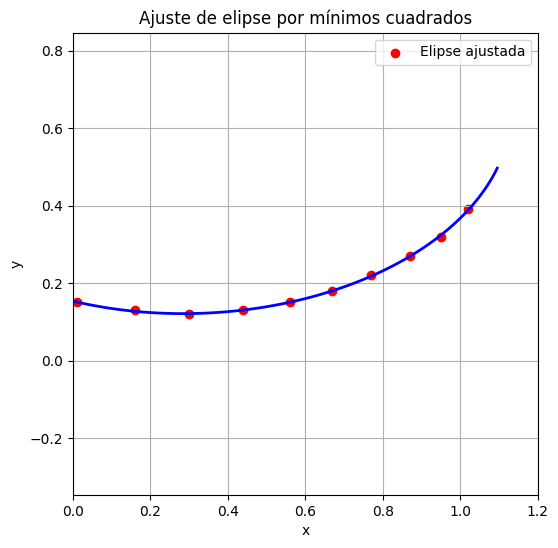

In [ ]:
import matplotlib.pyplot as plt
x = np.array([1.02, 0.95, 0.87, 0.77, 0.67, 0.56, 0.44, 0.30, 0.16, 0.01])
y = np.array([0.39, 0.32, 0.27, 0.22, 0.18, 0.15, 0.13, 0.12, 0.13, 0.15])
X = np.column_stack((y**2, x*y, x, y, np.ones_like(x)))
b = x**2
XTX = X.T @ X
XTb = X.T @ b
beta = np.linalg.solve(XTX, XTb)
A, B, C, D, E = beta
print("Coeficientes de la elipse (Ay^2 + Bxy + Cx + Dy + E = x^2):")
print(f"A = {A:.6f}")
print(f"B = {B:.6f}")
print(f"C = {C:.6f}")
print(f"D = {D:.6f}")
print(f"E = {E:.6f}")
plt.figure(figsize=(6, 6))
plt.scatter(x, y, color='red', label='Datos experimentales')
x_min, x_max = 0, 1.2
y_min, y_max = 0, 0.5
x_grid, y_grid = np.meshgrid(np.linspace(x_min, x_max, 200),
                             np.linspace(y_min, y_max, 200))
F = A * y_grid**2 + B * x_grid * y_grid + C * x_grid + D * y_grid + E - x_grid**2
plt.contour(x_grid, y_grid, F, levels=[0], colors='blue', linewidths=2, label='Elipse ajustada')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ajuste de elipse por mínimos cuadrados')
plt.legend(['Elipse ajustada', 'Datos experimentales'])
plt.grid(True)
plt.axis('equal')
plt.show()

* En la ecuación $Ay^2 + Bxy + Cx + Dy + E = x^2$, ¿por qué crees que el término $x^2$ se colocó del lado derecho de la igualdad en lugar de igualar toda la ecuación a cero? ¿Qué pasaría con el sistema de ecuaciones normales si igualáramos a cero?

El término $x^2$ se coloca a la derecha para actuar como el vector de términos independientes ($b$) en el sistema lineal $X\beta = b$. Si igualáramos la ecuación general a cero ($Ax^2 + Bxy + Cy^2 + Dx + Ey + F = 0$), el sistema de ecuaciones normales se volvería homogéneo ($X\beta = 0$), esto causaría que la solución por mínimos cuadrados colapsara en la solución trivial $\beta = 0$

* El método de mínimos cuadrados que acabas de programar minimiza el error de la ecuación algebraica propuesta. ¿Este error es exactamente el mismo que la distancia geométrica real (ortogonal) desde cada punto observado hasta el borde de la elipse trazada? Explica tu razonamiento.

No es el mismo ya que el algoritmo implementado minimiza el error algebraico, que se define como la diferencia residual $f(x_i, y_i) = Ay_i^2 + Bx_iy_i + Cx_i + Dy_i + E - x_i^2$, esta métrica mide qué tanto se desvía el punto de satisfacer numéricamente la igualdad algebraica, pero no representa una métrica espacial,  a distancia geométrica u ortogonal es la distancia euclidiana física más corta desde el punto $(x_i, y_i)$ hasta la curva de la elipse asi que minimizar la distancia geométrica requiere resolver un problema de optimización no lineal mucho más complejo (Mínimos Cuadrados Ortogonales), ya que la distancia geométrica no tiene una relación lineal con respecto a los parámetros $A, B, C, D, E$.
* De acuerdo con la Primera Ley de Kepler, los planetas describen órbitas elípticas donde la estrella ocupa uno de los focos de la elipse. Si ya calculaste los coeficientes $A, B, C, D, E$ y trazaste la elipse, ¿qué procedimientos matemáticos aplicarías para calcular las coordenadas exactas de la estrella $S$?

Para encontrar los focos, se deben aplicar los siguientes pasos.
  1. Rotación de ejes: Se define una matriz de la forma cuadrática para los términos de segundo grado, mediante la diagonalización de esta matriz, se obtiene el ángulo de rotación $\theta$ necesario para eliminar el término cruzado $Bxy$.
  2. Traslación de ejes: Tras aplicar la rotación, se realiza el método de completación de cuadrados perfectos para las variables modificadas asi permite llevar la ecuación a su forma canónica $\frac{(x')^2}{a^2} + \frac{(y')^2}{b^2} = 1$, de donde se extraen las coordenadas del centro $(h, k)$ y las longitudes de los semiejes mayor ($a$) y menor ($b$).
  3. Calcular la distancia focal ($c$): Utilizando la relación geométrica de la elipse, se calcula la distancia del centro a los focos como $c = \sqrt{a^2 - b^2}$.
  4. Determinación de los focos en coordenadas originales: Se ubican los focos a una distancia $c$ sobre el eje mayor en el sistema rotado y, finalmente, se aplica la matriz de transformación inversa para regresar dichos puntos a las coordenadas originales $(X, Y)$ por lo que uno de estos dos puntos vectoriales corresponderá a la posición exacta de la estrella $S$.

# Descomposición QR

## Ejercicio 3

Escribe un programa que, por medio de reflexiones de Householder, calcule la factorización $QR$ de una matriz de $m \times n$, con $m > n$.

Luego, prueba tu programa calculando la factorización de la siguiente matriz:

$$A = \begin{pmatrix}
1.0 & 1.0 & 1.5 \\
1.5 & 1.0 & 1.0 \\
1.0 & 1.5 & 1.0 \\
0.0 & 0.5 & -0.5 \\
-0.5 & 0.5 & 0.0
\end{pmatrix}$$

In [ ]:
import numpy as np
def qr_householder(A):
    m, n = A.shape
    R = A.astype(float).copy()
    Q = np.eye(m)
    for k in range(min(m - 1, n)):
        x = R[k:m, k]
        norm_x = np.linalg.norm(x)
        if norm_x == 0:
            continue
        sigma = norm_x if x[0] <= 0 else -norm_x
        v = x.copy()
        v[0] -= sigma
        norm_v = np.linalg.norm(v)
        if norm_v == 0:
            continue
        v = v / norm_v
        R[k:m, k:] -= 2.0 * np.outer(v, np.dot(v, R[k:m, k:]))
        R[k+1:m, k] = 0.0
        Q[:, k:m] -= 2.0 * np.dot(Q[:, k:m], np.outer(v, v))
    return Q, R
A = np.array([
    [ 1.0,  1.0,  1.5],
    [ 1.5,  1.0,  1.0],
    [ 1.0,  1.5,  1.0],
    [ 0.0,  0.5, -0.5],
    [-0.5,  0.5,  0.0]
])
Q, R = qr_householder(A)
np.set_printoptions(precision=4, suppress=True)

print("Matriz Q (Ortogonal)")
print(Q)
print("\nMatriz R (Triangular Superior)")
print(R)

Matriz Q (Ortogonal)
[[-0.4714  0.1307  0.621   0.5643 -0.2378]
 [-0.7071 -0.1961 -0.2942  0.0361  0.6113]
 [-0.4714  0.523  -0.0654 -0.6004 -0.3735]
 [ 0.      0.3922 -0.6864  0.5643 -0.2378]
 [ 0.2357  0.7191  0.2288  0.0361  0.6113]]

Matriz R (Triangular Superior)
[[-2.1213 -1.7678 -1.8856]
 [ 0.      1.2748  0.3269]
 [ 0.      0.      0.9152]
 [ 0.      0.      0.    ]
 [ 0.      0.      0.    ]]


* Una matriz de Householder $H = I - 2vv^T$ (con $\|v\| = 1$) representa una transformación lineal geométrica. ¿Qué le hace exactamente esta transformación a un vector en el espacio y por qué esto nos ayuda a triangularizar la matriz $A$?

Geométricamente, la matriz de Householder realiza una reflexión de cualquier vector en el espacio respecto al hiperplano ortogonal al vector unitario $v$,
  esta propiedad es fundamental para la triangularización debido a que nos permite elegir un vector $v$ tal que, al aplicar la reflexión a una columna cualquiera $x$ de la matriz $A$, todos sus componentes por debajo de una posición fija se anulen, al aplicar sucesivamente estas reflexiones columna por columna, se eliminan de forma sistemática los elementos debajo de la diagonal principal, lo que permite transformar la matriz original $A$ en una matriz triangular superior $R$.
* Si tu programa calculó correctamente la factorización $A = QR$, ¿qué propiedades matemáticas estrictas deben cumplir las matrices resultantes $Q$ y $R$? ¿Cómo podrías comprobar en tu código que $Q$ es correcta utilizando solo una multiplicación de matrices?

Las propiedades estrictas que deben cumplir son:
  1. **$Q$ debe ser una matriz ortogonal:** Significa que sus columnas forman un conjunto ortonormal, cumpliendo de manera estricta que $Q^T Q = Q Q^T = I$ (donde $I$ es la matriz identidad).
  2. **$R$ debe ser una matriz triangular superior:** Todos los elementos por debajo de la diagonal principal deben ser estrictamente cero ($r_{ij} = 0$ para todo $i > j$).
  
  Para comprobar de forma directa en el código que $Q$ conserva su ortogonalidad matemática mediante una sola multiplicación matricial, puedes evaluar el producto de $Q^T$ por sí misma. En Python, utilizando NumPy, la línea de validación sería:
  ```python
  # Si el resultado es idéntico a la matriz identidad, Q es ortogonal:
  print(Q.T @ Q)
  ```
* Existe otro método muy famoso para calcular la factorización $QR$ llamado proceso de ortogonalización de Gram-Schmidt. ¿Por qué en la práctica profesional de métodos numéricos se prefiere utilizar las reflexiones de Householder en lugar de Gram-Schmidt puro?

Gram-Schmidt construye la ortogonalidad desde cero y el error de redondeo la destruye en el camino, en cambio Householder utiliza herramientas que ya son intrínsecamente ortogonales (reflexiones), por lo que el error numérico nunca se sale de control





## Ejercicio 4

Considera los datos de la siguiente tabla:

| $x$ | -3.0 | -2.0 | -1.0 | 0.0 | 1.0 | 2.0 | 3.0 | 4.0 | 5.0 |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| $y$ | 118.61 | 46.11 | -13.59 | -3.07 | 3.41 | 23.88 | 76.41 | 179.0 | 349.2 |

Escribe un programa que, utilizando el método de factorización $QR$, encuentre el polinomio de grado 3 que mejor se ajuste a los datos de la tabla. Calcula los errores de ajuste y grafica el polinomio resultante junto con los datos experimentales.

A continuación, escribe un programa que utilice el mismo método de factorización $QR$ para hallar el polinomio de grado 2 que mejor se ajuste a los mismos datos. Calcula sus errores respectivos y grafícalo.



Coeficientes del polinomio de grado 3:
a0 = -15.079199
a1 = -10.854509
a2 = 12.644805
a3 = 0.745354

Errores de ajuste:
Suma de cuadrados de residuos: 1289.906740
Error cuadrático medio (MSE): 143.322971
Raíz del error cuadrático medio (RMSE): 11.971757


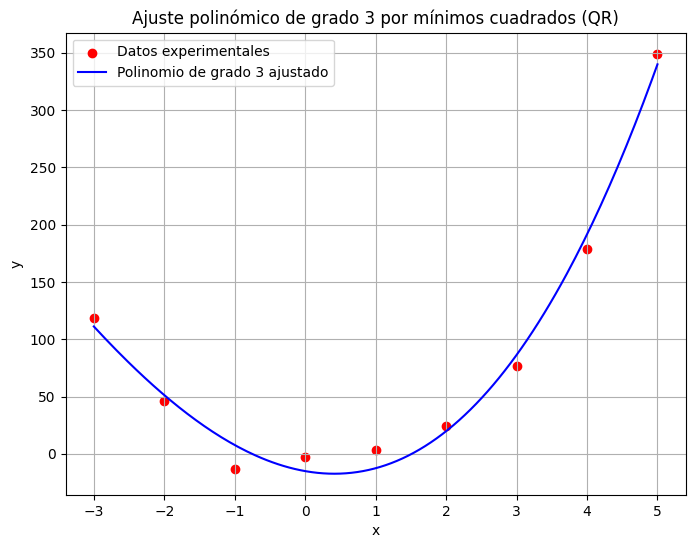

In [ ]:

x = np.array([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0])
y = np.array([118.61, 46.11, -13.59, -3.07, 3.41, 23.88, 76.41, 179.0, 349.2])

X = np.column_stack((np.ones_like(x), x, x**2, x**3))

Q, R = np.linalg.qr(X, mode='reduced')

a = np.linalg.solve(R, Q.T @ y)

a0, a1, a2, a3 = a
print("Coeficientes del polinomio de grado 3:")
print(f"a0 = {a0:.6f}")
print(f"a1 = {a1:.6f}")
print(f"a2 = {a2:.6f}")
print(f"a3 = {a3:.6f}")

y_pred = X @ a

residuos = y - y_pred
suma_cuadrados_residuos = np.sum(residuos**2)
error_cuadratico_medio = suma_cuadrados_residuos / len(y)
raiz_error_cuadratico_medio = np.sqrt(error_cuadratico_medio)
print("\nErrores de ajuste:")
print(f"Suma de cuadrados de residuos: {suma_cuadrados_residuos:.6f}")
print(f"Error cuadrático medio (MSE): {error_cuadratico_medio:.6f}")
print(f"Raíz del error cuadrático medio (RMSE): {raiz_error_cuadratico_medio:.6f}")

x_continuo = np.linspace(min(x), max(x), 200)
X_continuo = np.column_stack((np.ones_like(x_continuo), x_continuo, x_continuo**2, x_continuo**3))
y_continuo = X_continuo @ a

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='red', label='Datos experimentales')
plt.plot(x_continuo, y_continuo, 'b-', label='Polinomio de grado 3 ajustado')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ajuste polinómico de grado 3 por mínimos cuadrados (QR)')
plt.legend()
plt.grid(True)
plt.show()

Coeficientes del polinomio de grado 2:
a0 = -23.129017
a1 = -4.295398
a2 = 14.880866

Errores de ajuste:
Suma de cuadrados de residuos: 2081.901518
Error cuadrático medio (MSE): 231.322391
Raíz del error cuadrático medio (RMSE): 15.209286


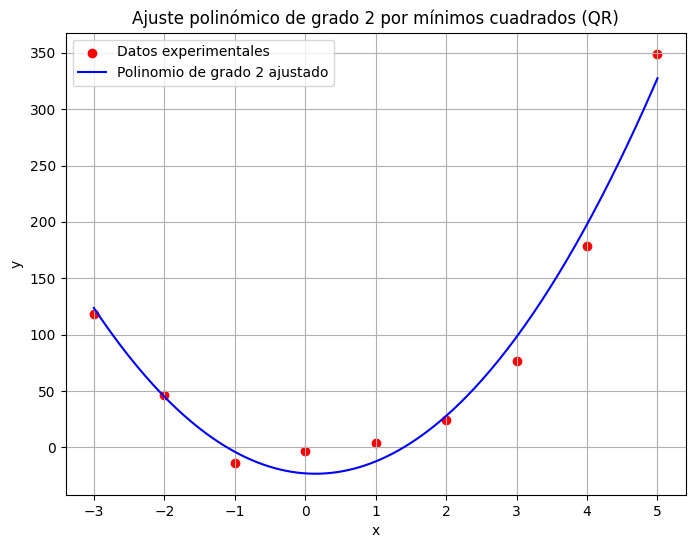

In [ ]:

x = np.array([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0])
y = np.array([118.61, 46.11, -13.59, -3.07, 3.41, 23.88, 76.41, 179.0, 349.2])

X = np.column_stack((np.ones_like(x), x, x**2))

Q, R = np.linalg.qr(X, mode='reduced')

a = np.linalg.solve(R, Q.T @ y)

a0, a1, a2 = a
print("Coeficientes del polinomio de grado 2:")
print(f"a0 = {a0:.6f}")
print(f"a1 = {a1:.6f}")
print(f"a2 = {a2:.6f}")

y_pred = X @ a

residuos = y - y_pred
suma_cuadrados_residuos = np.sum(residuos**2)
error_cuadratico_medio = suma_cuadrados_residuos / len(y)
raiz_error_cuadratico_medio = np.sqrt(error_cuadratico_medio)
print("\nErrores de ajuste:")
print(f"Suma de cuadrados de residuos: {suma_cuadrados_residuos:.6f}")
print(f"Error cuadrático medio (MSE): {error_cuadratico_medio:.6f}")
print(f"Raíz del error cuadrático medio (RMSE): {raiz_error_cuadratico_medio:.6f}")

x_continuo = np.linspace(min(x), max(x), 200)
X_continuo = np.column_stack((np.ones_like(x_continuo), x_continuo, x_continuo**2))
y_continuo = X_continuo @ a

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='red', label='Datos experimentales')
plt.plot(x_continuo, y_continuo, 'b-', label='Polinomio de grado 2 ajustado')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ajuste polinómico de grado 2 por mínimos cuadrados (QR)')
plt.legend()
plt.grid(True)
plt.show()

A partir de los resultados y gráficas obtenidos en ambos ajustes, responde:
* ¿Qué polinomio ajusta mejor los datos (tanto numérica como visualmente)?

El polinomio de grado 2.
* Escribe detalladamente tus observaciones, justificando por qué crees que un modelo resultó mejor que el otro.

Visual y numéricamente, ambos modelos presentan curvas casi idénticas, pero el modelo de grado 2 es superior porque describe la misma tendencia con menor complejidad computacional, evitando la sobreparametrización y coeficientes redundantes
* En los ejercicios anteriores utilizaste el método de Ecuaciones Normales ($A^TAx = A^Tb$) para mínimos cuadrados. ¿Por qué en la práctica computacional a menudo se prefiere resolver este mismo problema utilizando la factorización $QR$ en lugar de las ecuaciones normales directas?


Se prefiere QR por estabilidad numérica. En las ecuaciones normales, el número de condición se eleva al cuadrado ($\kappa(A^TA) = [\kappa(A)]^2$), lo que amplifica catastróficamente los errores de redondeo por punto flotante si la matriz está mal condicionada.
* Supongamos que para esta misma tabla de datos propusiéramos ajustar un polinomio de grado 8 (ya que tenemos 9 puntos de datos). El error de ajuste sería prácticamente cero. ¿Significa esto que el polinomio de grado 8 es el "mejor" modelo para describir el fenómeno físico detrás de estos datos? Explica tu respuesta.

 No, un error igual a cero en este caso representa un sobreajuste, el polinomio de grado 8 simplemente memoriza el ruido y el error experimental de los 9 puntos en lugar de capturar la ley física subyacente. Esto genera oscilaciones y destruye por completo la capacidad del modelo para predecir o interpolar valores nuevos de forma realista.
* Cuando el ejercicio pide "calcular los errores de ajuste", matemáticamente estás calculando la norma del vector residual $\|r\| = \|y - Ax\|$. Geométricamente en tu gráfica, ¿qué representan exactamente estos residuos antes de ser elevados al cuadrado o sumados?

Geométricamente los residuos representan las distancias verticales desde cada punto rojo hasta la curva azul del polinomio ajustado, su signo indica la posición del dato respecto al modelo: es positivo si el punto está por encima de la curva y negativo si está por debajo. El método de mínimos cuadrados busca minimizar la suma de los cuadrados de estas longitudes verticales.
